In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import numpy as np
import pandas as pd

In [49]:
df=pd.read_csv('/content/drive/MyDrive/Deep Learning/Lecture 11-20/Churn_Modelling.csv');

In [50]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [51]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [52]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [53]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [54]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [55]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [56]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [58]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# In keras we can build two types of models sequential and non sequential

In [59]:
model = Sequential()

In [60]:
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(5,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198 (792.00 B)

 Trainable params: 198 (792.00 B)

 Non-trainable params: 0 (0.00 B)

11 I/P - 3 nodes- 1 O/P

11*3 + 3 + 3*1+1 = 40 params

In [62]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])
# hame sathi sath accuracy bhi batata jayega

In [70]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_trf, y_train, test_size=0.2, random_state=0)

history = model.fit(tf.convert_to_tensor(X_train_final), tf.convert_to_tensor(y_train_final), epochs=100, validation_data=(tf.convert_to_tensor(X_val), tf.convert_to_tensor(y_val)))

# validation split matlab 100 data hai to 80 train 20 split or sathi hi sath
# har batch ke test se compare bhi karta jayega

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8644 - loss: 0.3285 - val_accuracy: 0.8631 - val_loss: 0.3389
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8647 - loss: 0.3285 - val_accuracy: 0.8662 - val_loss: 0.3385
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8652 - loss: 0.3286 - val_accuracy: 0.8644 - val_loss: 0.3380
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8650 - loss: 0.3283 - val_accuracy: 0.8650 - val_loss: 0.3371
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8661 - loss: 0.3286 - val_accuracy: 0.8662 - val_loss: 0.3368
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8647 - loss: 0.3276 - val_accuracy: 0.8650 - val_loss: 0.3385
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8655 - loss: 0.3279 - val_accuracy: 0.8644 - val_loss: 0.3379
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8670 - loss: 0.3279 - val_accu

In [71]:
model.layers[0].get_weights()

[array([[-0.13350639, -0.4134351 ,  0.08947842,  0.0253203 , -0.00794104,
         -0.01496181,  0.66497105, -0.03450883,  0.07614689, -0.05293936,
          0.33639386],
        [ 0.2561659 ,  0.63908064,  0.6542927 , -0.33805   , -0.62843686,
         -0.802856  , -0.7424747 , -0.02303809,  0.86720175, -0.49839386,
         -1.0124298 ],
        [ 0.30424356,  0.5921966 ,  0.2149217 , -0.07750899, -0.04860123,
          0.05814829, -0.80559754, -0.06762666,  0.22754475,  0.14498043,
         -0.06470922],
        [ 0.44562536, -0.5674777 , -0.33018726, -0.64843225,  0.299221  ,
          0.08173888, -0.94148314,  0.16378918, -0.13223931,  0.52850705,
         -0.5201527 ],
        [-0.37188032, -0.16090484, -0.24474862, -1.5296851 , -0.00784002,
         -0.0457469 ,  0.05236004,  1.2570007 ,  0.19844756, -0.3891274 ,
         -0.28058854],
        [ 0.21425226, -0.5098193 ,  0.974007  , -0.09950376, -0.13908415,
         -0.02231619, -0.47392747, -0.1806113 ,  0.2958882 , -0.4771693

# showss 33 weights of 11 into 3 and then shows 3 bias values


In [72]:
model.layers[1].get_weights()

[array([[-0.6679327 , -0.5547965 ,  0.35525435,  0.06168609,  0.7479663 ],
        [-0.29538676,  0.3918696 ,  0.654378  ,  0.3542941 ,  0.03724238],
        [ 0.14452422,  0.43232548,  0.45538557,  0.4410797 ,  0.5354804 ],
        [-0.07969762, -0.5087767 , -0.17639133, -0.57081157,  1.2785511 ],
        [ 0.16965395,  0.4550203 ,  0.40536883,  0.6285419 ,  0.17634064],
        [-0.4294457 ,  1.1251807 , -0.6165897 ,  0.53770185, -1.2447624 ],
        [-0.5874923 , -0.23051001, -0.0694228 ,  1.0993366 ,  0.17231281],
        [ 1.1204008 , -0.2575705 ,  0.5131573 , -0.35835367,  0.43060672],
        [-0.19381674,  0.8106307 ,  0.41274452,  0.27675417, -0.22393924],
        [ 0.6572641 , -0.05992725, -0.51211625, -0.6381886 ,  0.15692917],
        [ 0.08068612, -0.6077671 , -0.43168113,  0.4543291 , -0.6851259 ]],
       dtype=float32),
 array([ 0.25060618,  0.48709458, -0.12067579,  0.46284294,  0.01299241],
       dtype=float32)]

In [73]:
model.predict(X_test_trf)
# o/p 0 ya 1 nahi hai kyonki mai sigmoid functions use kar raha hu to always
# answer probabilty me ayega

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.2465767 ],
       [0.30114087],
       [0.11235318],
       ...,
       [0.11112462],
       [0.15340365],
       [0.1774087 ]], dtype=float32)

Here hame threshold decide karna padega jese 0.5 se zyadaa hai to 1 , to decide threshold we need to use auc - roc curve

In [74]:
y_log=model.predict(X_test_trf)
y_pred=np.where(y_log>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [75]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8555

In [76]:
import matplotlib.pyplot as plt

In [79]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

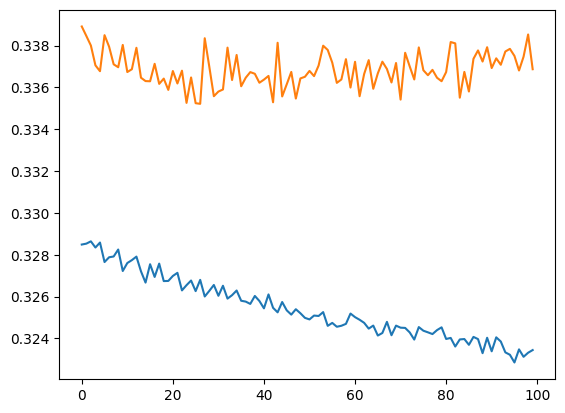

In [80]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

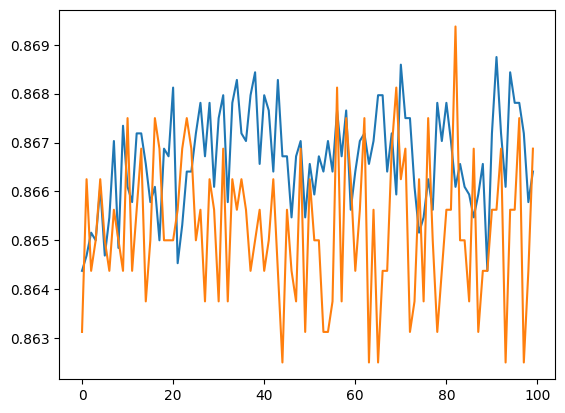

In [81]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])